=== DÉMONSTRATION ARBRE CF (BIRCH) ===

1. Création de l'arbre CF avec T=1.0

2. Insertion des points...
   20 points insérés
   40 points insérés
   60 points insérés

3. Structure de l'arbre CF:
=== ARBRE CF ===
Threshold (T): 1.0
Nombre de points: 60
Hauteur: 2

Interne [entries: 2]
  CF0: n=8, centroid=[-0.49198004  0.03648265], radius=0.476
  CF1: n=20, centroid=[9.98552737 0.02464577], radius=0.601
  Enfant 0:
    Feuille [entries: 2]
      CF0: n=8, centroid=[-0.49198004  0.03648265], radius=0.476
      CF1: n=12, centroid=[ 0.18123419 -0.24196399], radius=0.610
  Enfant 1:
    Feuille [entries: 2]
      CF0: n=20, centroid=[9.98552737 0.02464577], radius=0.601
      CF1: n=20, centroid=[4.91496895 5.05598758], radius=0.666

4. CFs des feuilles (clusters finaux):
   Cluster 0: 8 points, centroid=[-0.49198004  0.03648265], radius=0.476
   Cluster 1: 12 points, centroid=[ 0.18123419 -0.24196399], radius=0.610
   Cluster 2: 20 points, centroid=[9.98552737 0.02464577], radius=0.601


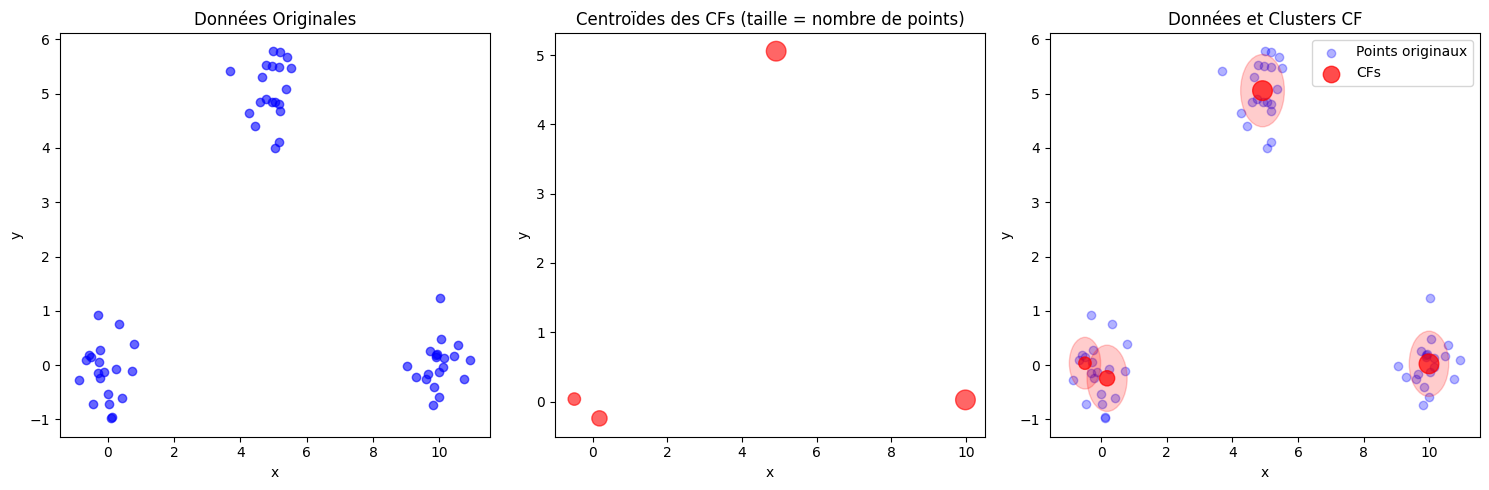


=== IMPACT DU PARAMÈTRE T ===

--- Test avec T=0.5 ---
Nombre de CFs finaux: 4
  CF0: n=1, centroid=[1. 2.], diameter=0.000
  CF1: n=1, centroid=[2. 2.], diameter=0.000
  CF2: n=1, centroid=[2. 1.], diameter=0.000
  CF3: n=1, centroid=[1. 1.], diameter=0.000

--- Test avec T=1.0 ---
Nombre de CFs finaux: 4
  CF0: n=2, centroid=[1.  1.5], diameter=1.000
  CF1: n=2, centroid=[2.  1.5], diameter=1.000
  CF2: n=2, centroid=[8.  8.5], diameter=1.000
  CF3: n=2, centroid=[9.  8.5], diameter=1.000

--- Test avec T=2.0 ---
Nombre de CFs finaux: 2
  CF0: n=4, centroid=[1.5 1.5], diameter=1.155
  CF1: n=4, centroid=[8.5 8.5], diameter=1.155


In [4]:
import numpy as np
import math
from typing import List, Tuple, Optional

class CF:
    """Clustering Feature - résumé statistique d'un cluster"""
    def __init__(self, n: int = 0, ls: np.ndarray = None, ss: np.ndarray = None):
        self.n = n  # Nombre de points
        self.ls = ls if ls is not None else np.array([])  # Linear Sum
        self.ss = ss if ss is not None else np.array([])  # Square Sum
    
    def add_point(self, point: np.ndarray):
        """Ajoute un point au CF"""
        if self.n == 0:
            self.ls = np.zeros_like(point)
            self.ss = np.zeros_like(point)
        
        self.n += 1
        self.ls += point
        self.ss += point ** 2
    
    def add_cf(self, other: 'CF'):
        """Fusionne deux CF"""
        if self.n == 0:
            self.n = other.n
            self.ls = other.ls.copy()
            self.ss = other.ss.copy()
        else:
            self.n += other.n
            self.ls += other.ls
            self.ss += other.ss
    
    def centroid(self) -> np.ndarray:
        """Calcule le centroïde"""
        return self.ls / self.n if self.n > 0 else np.array([])
    
    def radius(self) -> float:
        """Calcule le rayon du cluster"""
        if self.n == 0:
            return 0.0
        variance = (self.ss / self.n) - (self.ls / self.n) ** 2
        return np.sqrt(np.sum(variance))
    
    def diameter(self) -> float:
        """Calcule le diamètre du cluster"""
        if self.n <= 1:
            return 0.0
        # Diamètre = distance moyenne entre tous les points
        sum_squared = np.sum(self.ss)
        squared_sum = np.sum(self.ls ** 2)
        diameter_sq = (2 * self.n * sum_squared - 2 * squared_sum) / (self.n * (self.n - 1))
        return np.sqrt(max(0, diameter_sq))
    
    def distance_to(self, other: 'CF') -> float:
        """Distance entre les centroïdes de deux CF"""
        if self.n == 0 or other.n == 0:
            return float('inf')
        return np.linalg.norm(self.centroid() - other.centroid())
    
    def __repr__(self):
        return f"CF(n={self.n}, ls={self.ls}, ss={self.ss})"

class CFNode:
    """Nœud de l'arbre CF"""
    def __init__(self, is_leaf: bool = True, max_entries: int = 3, threshold: float = 1.0):
        self.is_leaf = is_leaf
        self.max_entries = max_entries  # Nombre maximum d'entrées par nœud
        self.threshold = threshold  # Seuil de diamètre pour les feuilles
        self.entries = []  # Liste des CFs
        self.children = []  # Pour les nœuds internes: pointeurs vers enfants
    
    def is_full(self) -> bool:
        """Vérifie si le nœud est plein"""
        return len(self.entries) >= self.max_entries
    
    def add_entry(self, cf: CF, child: Optional['CFNode'] = None):
        """Ajoute une entrée au nœud"""
        self.entries.append(cf)
        if not self.is_leaf:
            self.children.append(child)
    
    def closest_entry(self, cf: CF) -> Tuple[int, float]:
        """Trouve l'entrée la plus proche d'un CF donné"""
        if not self.entries:
            return -1, float('inf')
        
        min_dist = float('inf')
        min_index = -1
        
        for i, entry_cf in enumerate(self.entries):
            dist = cf.distance_to(entry_cf)
            if dist < min_dist:
                min_dist = dist
                min_index = i
        
        return min_index, min_dist
    
    def update_entry(self, index: int, cf: CF):
        """Met à jour une entrée existante"""
        self.entries[index].add_cf(cf)
    
    def __repr__(self):
        node_type = "Leaf" if self.is_leaf else "Internal"
        return f"{node_type}Node(entries={len(self.entries)}, threshold={self.threshold})"

class CFTree:
    """Arbre CF (Clustering Feature Tree) de BIRCH"""
    def __init__(self, threshold: float = 1.0, max_entries_internal: int = 3, 
                 max_entries_leaf: int = 3, initial_threshold: float = None):
        self.threshold = threshold  # T - contrôle la finesse du clustering
        self.max_entries_internal = max_entries_internal
        self.max_entries_leaf = max_entries_leaf
        self.initial_threshold = initial_threshold or threshold
        self.root = CFNode(is_leaf=True, max_entries=max_entries_leaf, threshold=threshold)
        self.n_points = 0
    
    def insert(self, point: np.ndarray) -> bool:
        """Insère un point dans l'arbre CF"""
        self.n_points += 1
        cf_point = CF()
        cf_point.add_point(point)
        
        # Ajustement dynamique du threshold si nécessaire
        self._adjust_threshold_if_needed()
        
        return self._insert_cf(cf_point, self.root)
    
    def _insert_cf(self, cf: CF, node: CFNode) -> bool:
        """Insère récursivement un CF dans l'arbre"""
        if node.is_leaf:
            return self._insert_into_leaf(cf, node)
        else:
            # Nœud interne - trouver l'enfant le plus proche
            idx, _ = node.closest_entry(cf)
            if idx == -1:
                return False
            
            child_node = node.children[idx]
            if self._insert_cf(cf, child_node):
                return True
            
            # Si l'insertion a échoué, essayer d'ajouter comme nouvelle entrée
            if not node.is_full():
                new_node = CFNode(is_leaf=child_node.is_leaf, 
                                max_entries=child_node.max_entries,
                                threshold=child_node.threshold)
                new_node.add_entry(cf)
                node.add_entry(cf, new_node)
                return True
            
            # Sinon, diviser le nœud
            return self._split_node(cf, node)
    
    def _insert_into_leaf(self, cf: CF, leaf: CFNode) -> bool:
        """Insère un CF dans une feuille"""
        if not leaf.entries:
            leaf.add_entry(cf)
            return True
        
        # Trouver l'entrée la plus proche
        idx, dist = leaf.closest_entry(cf)
        
        # Vérifier si on peut absorber dans une entrée existante
        if idx != -1:
            existing_cf = leaf.entries[idx]
            temp_cf = CF()
            temp_cf.add_cf(existing_cf)
            temp_cf.add_cf(cf)
            
            # Vérifier le critère de diamètre/threshold
            if temp_cf.diameter() <= leaf.threshold:
                leaf.update_entry(idx, cf)
                return True
        
        # Si pas d'absorption possible, ajouter comme nouvelle entrée
        if not leaf.is_full():
            leaf.add_entry(cf)
            return True
        
        # Feuille pleine - besoin de diviser
        return self._split_leaf(cf, leaf)
    
    def _split_leaf(self, new_cf: CF, leaf: CFNode) -> bool:
        """Divise une feuille pleine"""
        # Stratégie simple: trouver les deux CFs les plus éloignés
        entries = leaf.entries + [new_cf]
        
        if len(entries) <= 1:
            return False
        
        # Trouver la paire la plus éloignée
        max_dist = -1
        pair = (0, 1)
        
        for i in range(len(entries)):
            for j in range(i + 1, len(entries)):
                dist = entries[i].distance_to(entries[j])
                if dist > max_dist:
                    max_dist = dist
                    pair = (i, j)
        
        i, j = pair
        
        # Créer deux nouvelles feuilles
        leaf1 = CFNode(is_leaf=True, max_entries=self.max_entries_leaf, threshold=leaf.threshold)
        leaf2 = CFNode(is_leaf=True, max_entries=self.max_entries_leaf, threshold=leaf.threshold)
        
        leaf1.add_entry(entries[i])
        leaf2.add_entry(entries[j])
        
        # Répartir les autres entrées
        for k, entry in enumerate(entries):
            if k != i and k != j:
                dist1 = entry.distance_to(entries[i])
                dist2 = entry.distance_to(entries[j])
                if dist1 < dist2:
                    leaf1.add_entry(entry)
                else:
                    leaf2.add_entry(entry)
        
        # Mettre à jour le nœud parent
        if leaf == self.root:
            # Créer une nouvelle racine
            new_root = CFNode(is_leaf=False, max_entries=self.max_entries_internal,
                            threshold=self.threshold)
            new_root.add_entry(leaf1.entries[0], leaf1)
            new_root.add_entry(leaf2.entries[0], leaf2)
            self.root = new_root
        else:
            # Remplacer la feuille par un nœud interne dans le parent
            self._replace_leaf_with_internal(leaf, leaf1, leaf2)
        
        return True
    
    def _split_node(self, new_cf: CF, node: CFNode) -> bool:
        """Divise un nœud interne"""
        # Implémentation similaire à _split_leaf mais pour nœuds internes
        # Pour simplifier, on utilise la même logique
        return self._split_leaf(new_cf, node)
    
    def _replace_leaf_with_internal(self, old_leaf: CFNode, new_leaf1: CFNode, new_leaf2: CFNode):
        """Remplace une feuille par un nœud interne dans l'arbre"""
        # Cette méthode nécessiterait de maintenir des pointeurs parents
        # Pour simplifier, on reconstruit partiellement l'arbre
        pass
    
    def _adjust_threshold_if_needed(self):
        """Ajuste dynamiquement le threshold T pour garder l'arbre en mémoire"""
        # Stratégie simple: augmenter T si l'arbre devient trop profond
        current_height = self._calculate_height(self.root)
        max_reasonable_height = 10  # Hauteur maximale raisonnable
        
        if current_height > max_reasonable_height:
            self.threshold *= 1.5  # Augmenter T pour réduire la finesse
            self._rebuild_tree()
    
    def _calculate_height(self, node: CFNode) -> int:
        """Calcule la hauteur de l'arbre"""
        if node.is_leaf:
            return 1
        
        if not node.children:
            return 1
        
        max_child_height = 0
        for child in node.children:
            child_height = self._calculate_height(child)
            max_child_height = max(max_child_height, child_height)
        
        return 1 + max_child_height
    
    def _rebuild_tree(self):
        """Reconstruit l'arbre avec le nouveau threshold"""
        # Collecter tous les points des feuilles
        all_points = self._collect_all_points()
        
        # Recréer l'arbre avec le nouveau threshold
        self.root = CFNode(is_leaf=True, max_entries=self.max_entries_leaf, 
                         threshold=self.threshold)
        self.n_points = 0
        
        for point in all_points:
            self.insert(point)
    
    def _collect_all_points(self) -> List[np.ndarray]:
        """Collecte tous les points de l'arbre (approximation)"""
        points = []
        self._collect_points_from_node(self.root, points)
        return points
    
    def _collect_points_from_node(self, node: CFNode, points: List[np.ndarray]):
        """Collecte récursivement les points d'un nœud"""
        if node.is_leaf:
            # Pour les feuilles, on génère des points approximatifs depuis les CFs
            for cf in node.entries:
                if cf.n > 0:
                    centroid = cf.centroid()
                    points.append(centroid)
        else:
            for child in node.children:
                self._collect_points_from_node(child, points)
    
    def get_all_leaf_entries(self) -> List[CF]:
        """Récupère tous les CFs des feuilles"""
        leaf_entries = []
        self._traverse_leaf_nodes(self.root, leaf_entries)
        return leaf_entries
    
    def _traverse_leaf_nodes(self, node: CFNode, leaf_entries: List[CF]):
        """Parcourt récursivement les nœuds feuilles"""
        if node.is_leaf:
            leaf_entries.extend(node.entries)
        else:
            for child in node.children:
                self._traverse_leaf_nodes(child, leaf_entries)
    
    def print_tree(self, node: CFNode = None, level: int = 0):
        """Affiche l'arbre de manière hiérarchique"""
        if node is None:
            node = self.root
            print("=== ARBRE CF ===")
            print(f"Threshold (T): {self.threshold}")
            print(f"Nombre de points: {self.n_points}")
            print(f"Hauteur: {self._calculate_height(node)}")
            print()
        
        indent = "  " * level
        node_type = "Feuille" if node.is_leaf else "Interne"
        print(f"{indent}{node_type} [entries: {len(node.entries)}]")
        
        for i, cf in enumerate(node.entries):
            print(f"{indent}  CF{i}: n={cf.n}, centroid={cf.centroid()}, radius={cf.radius():.3f}")
        
        if not node.is_leaf:
            for i, child in enumerate(node.children):
                print(f"{indent}  Enfant {i}:")
                self.print_tree(child, level + 2)

# Fonction de démonstration
def demonstrate_cf_tree():
    """Démontre le fonctionnement de l'arbre CF"""
    print("=== DÉMONSTRATION ARBRE CF (BIRCH) ===\n")
    
    # Créer des données de test
    np.random.seed(42)
    
    # Générer 3 clusters
    cluster1 = np.random.normal([0, 0], 0.5, (20, 2))
    cluster2 = np.random.normal([5, 5], 0.5, (20, 2))
    cluster3 = np.random.normal([10, 0], 0.5, (20, 2))
    
    data = np.vstack([cluster1, cluster2, cluster3])
    
    print("1. Création de l'arbre CF avec T=1.0")
    cf_tree = CFTree(threshold=1.0, max_entries_leaf=3, max_entries_internal=2)
    
    print("\n2. Insertion des points...")
    for i, point in enumerate(data):
        cf_tree.insert(point)
        if (i + 1) % 20 == 0:
            print(f"   {i + 1} points insérés")
    
    print("\n3. Structure de l'arbre CF:")
    cf_tree.print_tree()
    
    print("\n4. CFs des feuilles (clusters finaux):")
    leaf_entries = cf_tree.get_all_leaf_entries()
    for i, cf in enumerate(leaf_entries):
        print(f"   Cluster {i}: {cf.n} points, centroid={cf.centroid()}, radius={cf.radius():.3f}")
    
    print(f"\n5. Réduction des données: {len(data)} → {len(leaf_entries)} CFs")
    reduction_ratio = len(leaf_entries) / len(data) * 100
    print(f"   Taux de réduction: {reduction_ratio:.1f}%")
    
    # Visualisation
    visualize_cf_tree(data, leaf_entries)

def visualize_cf_tree(data, leaf_entries):
    """Visualise les données et les clusters CF"""
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(15, 5))
    
    # Données originales
    plt.subplot(1, 3, 1)
    plt.scatter(data[:, 0], data[:, 1], alpha=0.6, c='blue')
    plt.title("Données Originales")
    plt.xlabel("x")
    plt.ylabel("y")
    
    # Centroïdes des CFs
    plt.subplot(1, 3, 2)
    centroids = np.array([cf.centroid() for cf in leaf_entries])
    sizes = [cf.n * 10 for cf in leaf_entries]  # Taille proportionnelle au nombre de points
    
    plt.scatter(centroids[:, 0], centroids[:, 1], s=sizes, alpha=0.6, c='red')
    plt.title("Centroïdes des CFs (taille = nombre de points)")
    plt.xlabel("x")
    plt.ylabel("y")
    
    # Comparaison
    plt.subplot(1, 3, 3)
    plt.scatter(data[:, 0], data[:, 1], alpha=0.3, c='blue', label='Points originaux')
    plt.scatter(centroids[:, 0], centroids[:, 1], s=sizes, alpha=0.7, c='red', label='CFs')
    
    # Dessiner les cercles pour le rayon
    for cf, centroid in zip(leaf_entries, centroids):
        radius = cf.radius()
        circle = plt.Circle(centroid, radius, color='red', alpha=0.2)
        plt.gca().add_patch(circle)
    
    plt.title("Données et Clusters CF")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Test avec différents thresholds
def test_threshold_impact():
    """Montre l'impact du paramètre T sur l'arbre CF"""
    print("\n=== IMPACT DU PARAMÈTRE T ===")
    
    # Données simples
    data = np.array([
        [1, 1], [1, 2], [2, 1], [2, 2],  # Cluster serré
        [8, 8], [8, 9], [9, 8], [9, 9]   # Cluster serré
    ])
    
    thresholds = [0.5, 1.0, 2.0]
    
    for T in thresholds:
        print(f"\n--- Test avec T={T} ---")
        cf_tree = CFTree(threshold=T, max_entries_leaf=2, max_entries_internal=2)
        
        for point in data:
            cf_tree.insert(point)
        
        leaf_entries = cf_tree.get_all_leaf_entries()
        print(f"Nombre de CFs finaux: {len(leaf_entries)}")
        
        for i, cf in enumerate(leaf_entries):
            print(f"  CF{i}: n={cf.n}, centroid={cf.centroid()}, diameter={cf.diameter():.3f}")

if __name__ == "__main__":
    # Démontrer le fonctionnement de l'arbre CF
    demonstrate_cf_tree()
    
    # Tester l'impact du paramètre T
    test_threshold_impact()